<a href="https://colab.research.google.com/github/hoangnguyen31251023514-sudo/tri-tue-nhan-tao/blob/main/m%C3%B3n_%C4%83n_vi%E1%BB%87t_nam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import load_img, img_to_array

# 1. TIỀN XỬ LÝ DỮ LIỆU
# SỬA TẠI ĐÂY: Đường dẫn tới thư mục 5 món ăn trên Drive của bạn
train_dir = "/content/drive/MyDrive/đồ ăn việt nam"

# Kích thước ảnh và kích thước lô (giữ nguyên theo mẫu)
img_width, img_height = 200 , 200
batch_size = 32

# Tăng cường dữ liệu dành cho huấn luyện mô hình
train_datagen = ImageDataGenerator(
    rescale=1.0/255,  # Chuẩn hóa điểm ảnh về [0, 1]
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [16]:
# --- 1. CHUẨN HÓA VÀ TĂNG CƯỜNG DỮ LIỆU ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,           # Thêm cái này để tăng accuracy từ 0.4 lên cao!
    rotation_range=20,        # Xoay ảnh chống học vẹt
    zoom_range=0.2,           # Phóng to thu nhỏ
    horizontal_flip=True,     # Lật ảnh ngẫu nhiên
    validation_split=0.2      # Tự động chia 20% làm tập test
)

# ĐIỀN ĐƯỜNG DẪN THƯ MỤC DATA SAU KHI ÔNG GIẢI NÉN VÀO ĐÂY:
train_dir = '/content/drive/MyDrive/đồ ăn việt nam'

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),   # Đổi kích thước về 150x150 cho nhẹ và chuẩn
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 252 images belonging to 5 classes.
Found 61 images belonging to 5 classes.


In [17]:
# --- 2. XÂY DỰNG MẠNG CNN SÂU HƠN ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Giúp mô hình không bị học vẹt, tăng độ chính xác thực tế

    # ⚠️ CHÚ Ý: Sửa số 5 thành ĐÚNG SỐ LƯỢNG MÓN ĂN trong tập data của ông nhé!
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001), # Hạ learning rate xuống để máy học kỹ hơn
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
# --- 3. TIẾN HÀNH TRAIN ---
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2262 - loss: 1.6662 - val_accuracy: 0.2951 - val_loss: 1.5704
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 458ms/step - accuracy: 0.2302 - loss: 1.5859 - val_accuracy: 0.2951 - val_loss: 1.5558
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 346ms/step - accuracy: 0.2222 - loss: 1.5923 - val_accuracy: 0.2951 - val_loss: 1.5452
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 347ms/step - accuracy: 0.3135 - loss: 1.5418 - val_accuracy: 0.2951 - val_loss: 1.5271
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 340ms/step - accuracy: 0.3214 - loss: 1.5360 - val_accuracy: 0.2951 - val_loss: 1.5139
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 473ms/step - accuracy: 0.3413 - loss: 1.5250 - val_accuracy: 0.3115 - val_loss: 1.4948
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 409ms/step - accuracy: 0.3571 - loss: 1.4783 - val_accuracy: 0.2951 - val_loss: 1.4676
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 336ms/step - accuracy: 0.3373 - loss: 1.4381 - val_accuracy: 0.4098 - val_loss: 1

In [19]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

# Các đoạn code cũ của ông giữ nguyên bên dưới...
# img = load_img(path, target_size=(200, 200))
# ...

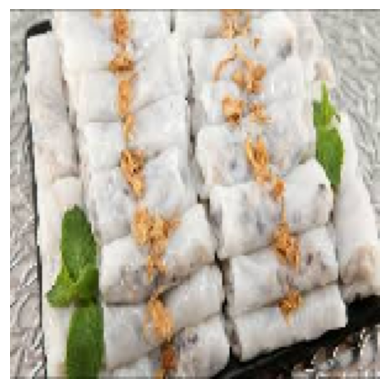

🔮 Đang ngửi mùi món ăn...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step

🎉 TING TING! Món này là: Bánh ướt (Máy tự tin: 85.14%)


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# 1. Điền lại đường dẫn bức ảnh ông muốn test vào đây
path = "/content/images - 2026-06-01T020118.826.jpg"

try:
    # 2. ÉP CHUẨN SIZE 150x150 (Tuyệt đối không dùng 200x200 nữa)
    img = load_img(path, target_size=(150, 150))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # 3. Chuẩn hóa ảnh mượt mà (Không dùng lệnh reshape dễ gây lỗi nữa)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0

    print("🔮 Đang ngửi mùi món ăn...")
    predictions = model.predict(x)

    # 4. Danh sách 5 món đặc sản của ông
    danh_sach_mon_an = ['Bánh ướt', 'Bún riêu', 'Bún đậu', 'Cơm tấm', 'Mì quảng']

    class_idx = np.argmax(predictions)
    ti_le = predictions[0][class_idx] * 100

    print(f"\n🎉 TING TING! Món này là: {danh_sach_mon_an[class_idx]} (Máy tự tin: {ti_le:.2f}%)")

except Exception as e:
    print(f"❌ Vẫn lỗi hả? Lỗi ở đây nè: {e}")